In [ ]:
'''
BT 1 - Source verb analysis based on Word Embedding.ipynb
Author: Muhammmad Talha & Jingchuan Shi
Supervisor: Dr. Ahmed Qureshi
Created 2019/9/6, last modified 2026/02/02 at University of Alberta.
All Rights Reserved.
'''

# Load relevant modules.
import numpy as np
import spacy
# nlp = spacy.load("en_core_web_lg") # Model en_vectors_web_lg of SpaCy with a pre-defined shortcut.


In [1]:
# === Runtime config & versions ===
import sys, platform, random, numpy as np, pandas as pd
import sklearn, spacy, pkgutil, datetime as dt
SEED = 42
random.seed(SEED); np.random.seed(SEED)

def show_versions():
    print("Run:", dt.datetime.now().isoformat())
    print("Python:", sys.version.split()[0], "| OS:", platform.platform())
    print("NumPy:", np.__version__, "| pandas:", pd.__version__)
    print("scikit-learn:", sklearn.__version__, "| spaCy:", spacy.__version__)
show_versions()


Run: 2025-12-17T22:53:42.075003
Python: 3.11.13 | OS: Windows-10-10.0.22631-SP0
NumPy: 1.26.4 | pandas: 2.3.3
scikit-learn: 1.7.2 | spaCy: 3.7.4


In [2]:
# === Embeddings (MPNet) ===
import numpy as np
from sentence_transformers import SentenceTransformer

_st = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
_embed_cache = {}

def embed(word: str) -> np.ndarray:
    w = word.strip().lower()
    if w in _embed_cache:
        return _embed_cache[w]
    v = _st.encode([w], normalize_embeddings=True, convert_to_numpy=True)[0].astype(np.float32, copy=False)
    _embed_cache[w] = v
    return v


C:\Users\talha4\AppData\Local\anaconda3\envs\bloom-nlp\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


In [3]:
# import spacy, importlib.metadata as ilmd
# print("spaCy version       :", spacy.__version__)
# print("Model en_core_web_lg:", ilmd.version("en_core_web_lg"))   # should print 3.7.3

# nlp = spacy.load("en_core_web_lg")          # should load silently
# print("Vector norm test:", nlp("evaluate").vector_norm)  # > 0  ⇒ all good


In [ ]:
# List of core verbs and their corresponding weights.
knowledge_words = ['list', 'name', 'define', 'repeat', 'state', 'label', 'recall', 'identify', 'reproduce', 'describe', 'recognize', 'select', 'record', 'match', 'relate', 'memorize', 'outline', 'quote', 'enumerate', 'write', 'tell', 'recite', 'cite', 'duplicate', 'read', 'order', 'tabulate', 'draw', 'review', 'indicate', 'underline', 'arrange', 'know', 'point', 'count', 'collect', 'meet', 'study', 'trace', 'find', 'index', 'locate', 'show', 'visualize', 'examine', 'copy', 'sequence', 'acquire', 'retell', 'view', 'observe', 'tally', 'imitate', 'follow']
knowledge_weights = [20, 18, 16, 15, 15, 14, 14, 13, 12, 12, 11, 10, 10, 9, 9, 9, 6, 6, 6, 6, 5, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
comprehension_words = ['explain', 'describe', 'discuss', 'paraphrase', 'restate', 'summarize', 'translate', 'convert', 'review', 'express', 'estimate', 'identify', 'generalize', 'interpret', 'locate', 'give', 'distinguish', 'extend', 'predict', 'recognize', 'defend', 'classify', 'infer', 'report', 'illustrate', 'rewrite', 'select', 'contrast', 'differentiate', 'compare', 'indicate', 'exemplify', 'observe', 'elaborate', 'associate', 'visualize', 'articulate', 'clarify', 'subtract', 'approximate', 'interpolate', 'tell', 'detail', 'outline', 'cite', 'picture', 'interact', 'conclude', 'characterize', 'add', 'factor', 'compute', 'match', 'schedule', 'order', 'sketch', 'draw', 'define', 'operate', 'arrange', 'group', 'extrapolate', 'diagram', 'interrelate', 'represent', 'trace', 'shop', 'suggest', 'understand']
comprehension_weights = [19, 18, 18, 14, 13, 13, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 9, 9, 8, 8, 7, 7, 7, 6, 5, 5, 5, 5, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
application_words = ['demonstrate', 'use', 'apply', 'solve', 'illustrate', 'dramatize', 'practise', 'employ', 'operate', 'sketch', 'prepare', 'show', 'compute', 'relate', 'construct', 'interpret', 'discover', 'change', 'produce', 'manipulate', 'schedule', 'modify', 'predict', 'complete', 'choose', 'classify', 'translate', 'determine', 'examine', 'calculate', 'investigate', 'draw', 'write', 'protect', 'derive', 'chart', 'alphabetize', 'simulate', 'process', 'provide', 'capture', 'project', 'transcribe', 'organize', 'shop', 'establish', 'attain', 'graph', 'assign', 'allocate', 'convert', 'experiment', 'exercise', 'diminish', 'make', 'develop', 'ascertain', 'tabulate', 'depreciate', 'subscribe', 'implement', 'handle', 'transfer', 'factor', 'avoid', 'expose', 'express', 'perform', 'sequence', 'acquire', 'administer', 'personalize', 'adapt', 'plot', 'customize', 'interview', 'paint', 'explore', 'utilize', 'report', 'figure', 'price', 'coordinate', 'simplify', 'consult', 'maintain', 'deliver', 'extend', 'imitate', 'guide', 'conduct', 'multiply', 'build', 'code', 'contribute', 'obtain', 'model', 'compare', 'divide', 'exhibit', 'tally', 'inform', 'diagram', 'expand', 'amend', 'engineer', 'control', 'assess', 'concatenate', 'execute', 'convey', 'articulate', 'restructure', 'criticize', 'appraise', 'participate', 'generalize', 'instruct', 'follow', 'act', 'screen', 'debate', 'question', 'select', 'include', 'dissect', 'retrieve', 'inspect', 'prove', 'inventory', 'respond', 'comply', 'collect']
application_weights = [18, 17, 17, 17, 15, 13, 13, 12, 12, 11, 11, 11, 10, 10, 10, 10, 9, 9, 9, 8, 8, 8, 8, 6, 6, 6, 5, 5, 5, 5, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
analysis_words = ['compare', 'contrast', 'distinguish', 'analyze', 'differentiate', 'separate', 'examine', 'diagram', 'infer', 'categorize', 'experiment', 'discriminate', 'select', 'appraise', 'relate', 'test', 'question', 'classify', 'identify', 'outline', 'illustrate', 'subdivide', 'investigate', 'debate', 'criticize', 'calculate', 'inventory', 'prioritize', 'correlate', 'explain', 'inspect', 'detect', 'dissect', 'manage', 'audit', 'characterize', 'order', 'deduce', 'limit', 'connect', 'diagnose', 'document', 'proofread', 'discover', 'ensure', 'optimize', 'maximize', 'confirm', 'divide', 'transform', 'figure', 'prepare', 'file', 'determine', 'train', 'solve', 'survey', 'group', 'minimize', 'interrupt', 'explore', 'blueprint', 'arrange', 'query', 'edit', 'prove', 'isolate', 'reconcile', 'troubleshoot', 'sketch', 'create', 'summarize', 'dramatize', 'employ', 'inquire', 'link', 'abstract', 'establish', 'organize', 'compute', 'devise', 'moderate', 'delegate', 'research', 'model', 'practise', 'operate', 'demonstrate', 'schedule', 'check', 'use', 'chunk', 'choose', 'scrutinize', 'chart', 'apply', 'allow', 'extrapolate', 'recognize', 'show', 'modify', 'administer', 'review', 'change', 'monitor', 'direct', 'corroborate', 'produce', 'negotiate', 'probe', 'accept', 'design', 'interpret', 'extract', 'manipulate', 'focus', 'write', 'predict', 'resolve']
analysis_weights = [20, 19, 17, 17, 13, 12, 12, 10, 10, 9, 9, 8, 8, 8, 8, 8, 7, 7, 7, 7, 7, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 4, 4, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
synthesis_words = ['design', 'create', 'formulate', 'plan', 'compose', 'construct', 'develop', 'combine', 'assemble', 'propose', 'devise', 'arrange', 'organize', 'collect', 'rearrange', 'prepare', 'reconstruct', 'invent', 'generate', 'modify', 'write', 'categorize', 'rewrite', 'relate', 'compile', 'revise', 'reorganize', 'summarize', 'manage', 'generalize', 'integrate', 'explain', 'produce', 'originate', 'tell', 'incorporate', 'facilitate', 'hypothesize', 'substitute', 'specify', 'improve', 'format', 'correspond', 'model', 'depict', 'synthesize', 'refer', 'comply', 'enhance', 'import', 'overhaul', 'animate', 'predict', 'adapt', 'cultivate', 'code', 'join', 'handle', 'anticipate', 'portray', 'express', 'budget', 'cope', 'debug', 'perform', 'communicate', 'outline', 'prescribe', 'initiate', 'network', 'program', 'lecture', 'dictate', 'advise', 'document', 'gather', 'derive', 'abstract', 'expand', 'establish', 'collaborate', 'conduct', 'contribute', 'coordinate', 'compare', 'speculate', 'simulate', 'progress', 'forecast', 'instruct', 'structure', 'intervene', 'frame', 'measure', 'estimate', 'recommend', 'negotiate', 'consolidate', 'choose', 'contrast', 'imagine', 'individualize', 'recognize', 'solve', 'roleplay', 'review', 'arbitrate', 'teach', 'supervise', 'assess', 'counsel', 'exchange', 'brief', 'reinforce', 'unify', 'pretend', 'update', 'validate']
synthesis_weights = [20, 19, 18, 17, 16, 16, 13, 12, 12, 11, 10, 10, 10, 10, 9, 9, 9, 9, 8, 8, 8, 7, 7, 7, 7, 7, 7, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
evaluation_words = ['judge', 'appraise', 'evaluate', 'support', 'assess', 'select', 'justify', 'compare', 'rate', 'conclude', 'value', 'defend', 'estimate', 'choose', 'critique', 'argue', 'measure', 'recommend', 'discriminate', 'decide', 'interpret', 'criticize', 'contrast', 'rank', 'predict', 'explain', 'summarize', 'score', 'grade', 'revise', 'relate', 'verify', 'test', 'validate', 'attach', 'determine', 'describe', 'convince', 'prescribe', 'consider', 'release', 'counsel', 'hire', 'prioritize', 'deduce', 'enforce', 'advise', 'motivate', 'core', 'uphold', 'resolve', 'reconcile', 'discuss', 'authenticate', 'review', 'monitor', 'weigh', 'debate', 'diagnose', 'infer', 'mediate', 'prove', 'use', 'preserve', 'access', 'consolidate']
evaluation_weights = [21, 17, 17, 15, 15, 14, 14, 13, 13, 12, 10, 10, 10, 9, 9, 9, 9, 9, 8, 7, 7, 7, 6, 6, 6, 6, 6, 5, 5, 4, 4, 4, 4, 4, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
# knowledge_words_spacy = nlp(r'list name define repeat state label recall identify reproduce describe recognize select record match relate memorize outline quote enumerate write tell recite cite duplicate read order tabulate draw review indicate underline arrange know point count collect meet study trace find index locate show visualize examine copy sequence acquire retell view observe tally imitate follow')
# comprehension_words_spacy = nlp(r'explain describe discuss paraphrase restate summarize translate convert review express estimate identify generalize interpret locate give distinguish extend predict recognize defend classify infer report illustrate rewrite select contrast differentiate compare indicate exemplify observe elaborate associate visualize articulate clarify subtract approximate interpolate tell detail outline cite picture interact conclude characterize add factor compute match schedule order sketch draw define operate arrange group extrapolate diagram interrelate represent trace shop suggest understand')
# application_words_spacy = nlp(r'demonstrate use apply solve illustrate dramatize practise employ operate sketch prepare show compute relate construct interpret discover change produce manipulate schedule modify predict complete choose classify translate determine examine calculate investigate draw write protect derive chart alphabetize simulate process provide capture project transcribe organize shop establish attain graph assign allocate convert experiment exercise diminish make develop ascertain tabulate depreciate subscribe implement handle transfer factor avoid expose express perform sequence acquire administer personalize adapt plot customize interview paint explore utilize report figure price coordinate simplify consult maintain deliver extend imitate guide conduct multiply build code contribute obtain model compare divide exhibit tally inform diagram expand amend engineer control assess concatenate execute convey articulate restructure criticize appraise participate generalize instruct follow act screen debate question select include dissect retrieve inspect prove inventory respond comply collect')
# analysis_words_spacy = nlp(r'compare contrast distinguish analyze differentiate separate examine diagram infer categorize experiment discriminate select appraise relate test question classify identify outline illustrate subdivide investigate debate criticize calculate inventory prioritize correlate explain inspect detect dissect manage audit characterize order deduce limit connect diagnose document proofread discover ensure optimize maximize confirm divide transform figure prepare file determine train solve survey group minimize interrupt explore blueprint arrange query edit prove isolate reconcile troubleshoot sketch create summarize dramatize employ inquire link abstract establish organize compute devise moderate delegate research model practise operate demonstrate schedule check use chunk choose scrutinize chart apply allow extrapolate recognize show modify administer review change monitor direct corroborate produce negotiate probe accept design interpret extract manipulate focus write predict resolve')
# synthesis_words_spacy = nlp(r'design create formulate plan compose construct develop combine assemble propose devise arrange organize collect rearrange prepare reconstruct invent generate modify write categorize rewrite relate compile revise reorganize summarize manage generalize integrate explain produce originate tell incorporate facilitate hypothesize substitute specify improve format correspond model depict synthesize refer comply enhance import overhaul animate predict adapt cultivate code join handle anticipate portray express budget cope debug perform communicate outline prescribe initiate network program lecture dictate advise document gather derive abstract expand establish collaborate conduct contribute coordinate compare speculate simulate progress forecast instruct structure intervene frame measure estimate recommend negotiate consolidate choose contrast imagine individualize recognize solve roleplay review arbitrate teach supervise assess counsel exchange brief reinforce unify pretend update validate')
# evaluation_words_spacy = nlp(r'judge appraise evaluate support assess select justify compare rate conclude value defend estimate choose critique argue measure recommend discriminate decide interpret criticize contrast rank predict explain summarize score grade revise relate verify test validate attach determine describe convince prescribe consider release counsel hire prioritize deduce enforce advise motivate core uphold resolve reconcile discuss authenticate review monitor weigh debate diagnose infer mediate prove use preserve access consolidate')
wordlists = [knowledge_words, comprehension_words, application_words, analysis_words, synthesis_words, evaluation_words]
# wordlists_spacy = [knowledge_words_spacy, comprehension_words_spacy, application_words_spacy, analysis_words_spacy, synthesis_words_spacy, evaluation_words_spacy]
weights = [knowledge_weights, comprehension_weights, application_weights, analysis_weights, synthesis_weights, evaluation_weights]
namelist = ['knowledge', 'comprehension', 'application', 'analysis', 'synthesis', 'evaluation']

In [26]:
LEVELS = ["Kn","Cm","Ap","An","Sn","Ev"]

wordlists = [
    knowledge_words,
    comprehension_words,
    application_words,
    analysis_words,
    synthesis_words,
    evaluation_words
]

weights = [
    knowledge_weights,
    comprehension_weights,
    application_weights,
    analysis_weights,
    synthesis_weights,
    evaluation_weights
]

# High/low split (freq threshold f0=10 as in your manuscript)
f0 = 10
wordlists_high = [[w for w,wt in zip(ws,wts) if wt >= f0] for ws,wts in zip(wordlists, weights)]
wordlists_low  = [[w for w,wt in zip(ws,wts) if wt <  f0] for ws,wts in zip(wordlists, weights)]

# Sanity checks (should match paper)
total_entries = sum(len(ws) for ws in wordlists)
unique_verbs  = len(set([w for ws in wordlists for w in ws]))
print("Core unique verbs:", unique_verbs, "| Core entries:", total_entries)  # expect 358 / 559
print("High entries per level:", [len(x) for x in wordlists_high])
print("Low entries per level :", [len(x) for x in wordlists_low])


Core unique verbs: 358 | Core entries: 559
High entries per level: [13, 17, 16, 9, 14, 13]
Low entries per level : [41, 52, 117, 110, 104, 53]


In [27]:
import numpy as np, pandas as pd
from IPython.display import display

LEVELS = ["Kn","Cm","Ap","An","Sn","Ev"]

def centroid_from_words(words):
    V = np.vstack([embed(w) for w in words])            # each already L2-normalized
    mu = V.mean(axis=0)
    mu = mu / np.linalg.norm(mu)                        # normalize centroid
    return mu

def cosine_dist(a, b):
    # centroids are normalized => cosine distance = 1 - dot
    return 1.0 - float(np.dot(a, b))

def pairwise_centroid_table(wordlists, title, out_csv=None):
    C = [centroid_from_words(ws) for ws in wordlists]
    D = np.zeros((6,6), dtype=float)
    for i in range(6):
        for j in range(6):
            D[i,j] = cosine_dist(C[i], C[j])

    df = pd.DataFrame(D, index=LEVELS, columns=LEVELS)
    print("\n" + title)
    display(df.round(3))
    if out_csv:
        df.to_csv(out_csv, index=True)
    return D, df

def nominal_dn_from_pairwise(D):
    # d_n = mean of D(i, i+n) for i=1..6-n
    rows = []
    for n in range(1, 6):
        rows.append({"n": n, "d_n": float(np.mean(np.diag(D, k=n)))})
    return pd.DataFrame(rows)

# ---- Table 1/2/3 (NOW cosine distances in MPNet space) ----
D_all,  T1 = pairwise_centroid_table(wordlists,      "Table 1. Core (All) — centroid cosine distances", out_csv="T1_core_all.csv")
D_high, T2 = pairwise_centroid_table(wordlists_high, "Table 2. Core (High-frequency) — centroid cosine distances", out_csv="T2_core_high.csv")
D_low,  T3 = pairwise_centroid_table(wordlists_low,  "Table 3. Core (Low-frequency) — centroid cosine distances", out_csv="T3_core_low.csv")

print("\nNominal distances d_n (All core):")
display(nominal_dn_from_pairwise(D_all).round(3))
print("Nominal distances d_n (High core):")
display(nominal_dn_from_pairwise(D_high).round(3))
print("Nominal distances d_n (Low core):")
display(nominal_dn_from_pairwise(D_low).round(3))



Table 1. Core (All) — centroid cosine distances


,Kn,Cm,Ap,An,Sn,Ev
Kn,0.000,0.074,0.092,0.082,0.109,0.124
Cm,0.074,0.000,0.064,0.045,0.075,0.085
Ap,0.092,0.064,0.000,0.036,0.025,0.087
An,0.082,0.045,0.036,0.000,0.050,0.057
Sn,0.109,0.075,0.025,0.050,0.000,0.095
Ev,0.124,0.085,0.087,0.057,0.095,0.000



Table 2. Core (High-frequency) — centroid cosine distances


,Kn,Cm,Ap,An,Sn,Ev
Kn,0.000,0.222,0.317,0.412,0.394,0.315
Cm,0.222,0.000,0.213,0.263,0.325,0.207
Ap,0.317,0.213,0.000,0.359,0.197,0.275
An,0.412,0.263,0.359,0.000,0.428,0.294
Sn,0.394,0.325,0.197,0.428,0.000,0.347
Ev,0.315,0.207,0.275,0.294,0.347,0.000



Table 3. Core (Low-frequency) — centroid cosine distances


...

,n,d_n
0,1,0.064
1,2,0.055
2,3,0.082
3,4,0.097
4,5,0.124


Nominal distances d_n (High core):


,n,d_n
0,1,0.314
1,2,0.268
2,3,0.337
3,4,0.300
4,5,0.315


Nominal distances d_n (Low core):


,n,d_n
0,1,0.061
1,2,0.054
2,3,0.080
3,4,0.097
4,5,0.130


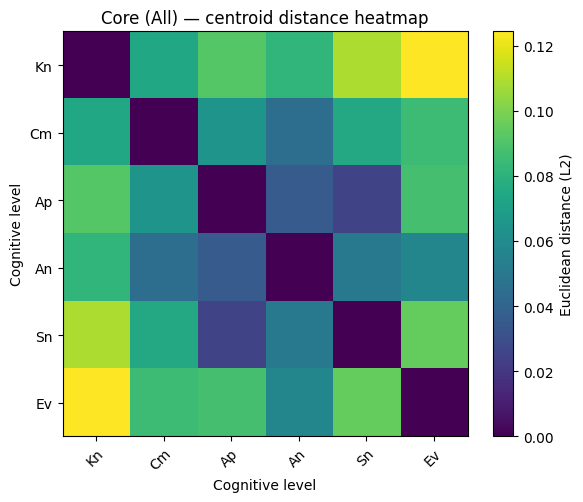

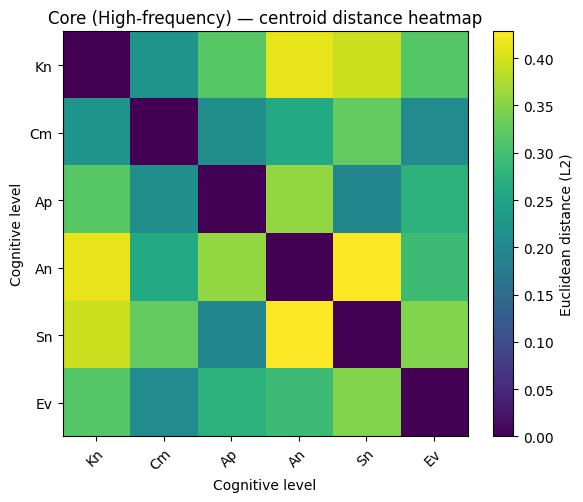

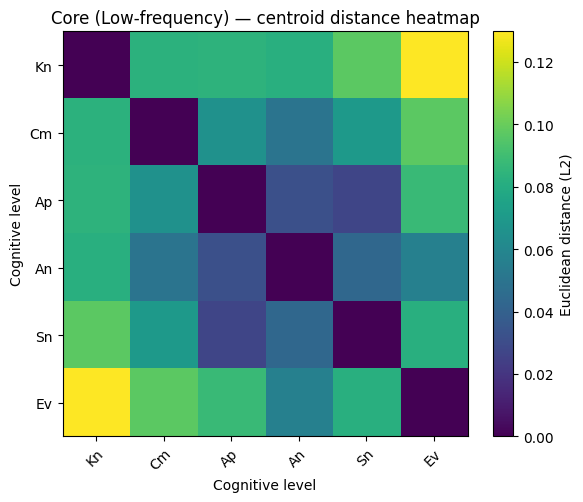

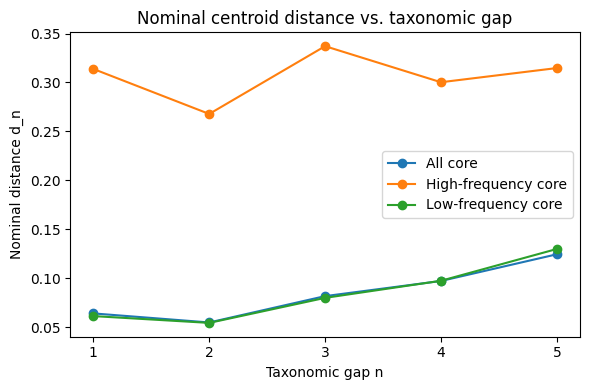

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes you already have:
# D_all, D_high, D_low (each 6x6 numpy array)
# LEVELS = ["Kn","Cm","Ap","An","Sn","Ev"]

def plot_heatmap(D, title, fname=None):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(D, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks(range(len(LEVELS))); ax.set_yticks(range(len(LEVELS)))
    ax.set_xticklabels(LEVELS); ax.set_yticklabels(LEVELS)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Euclidean distance (L2)")
    ax.set_xlabel("Cognitive level")
    ax.set_ylabel("Cognitive level")
    fig.tight_layout()
    if fname:
        fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

def nominal_dn(D):
    # d_n = average of nth superdiagonal
    return np.array([np.mean(np.diag(D, k=n)) for n in range(1, 6)], dtype=float)

def plot_nominal_curves(D_all, D_high, D_low, fname=None):
    n = np.arange(1, 6)
    dn_all  = nominal_dn(D_all)
    dn_high = nominal_dn(D_high)
    dn_low  = nominal_dn(D_low)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(n, dn_all,  marker="o", label="All core")
    ax.plot(n, dn_high, marker="o", label="High-frequency core")
    ax.plot(n, dn_low,  marker="o", label="Low-frequency core")
    ax.set_xticks(n)
    ax.set_xlabel("Taxonomic gap n")
    ax.set_ylabel("Nominal distance d_n")
    ax.set_title("Nominal centroid distance vs. taxonomic gap")
    ax.legend()
    fig.tight_layout()
    if fname:
        fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

# --- Heatmaps (paper-ready) ---
plot_heatmap(D_all,  "Core (All) — centroid distance heatmap", fname="Fig_core_all_heatmap.png")
plot_heatmap(D_high, "Core (High-frequency) — centroid distance heatmap", fname="Fig_core_high_heatmap.png")
plot_heatmap(D_low,  "Core (Low-frequency) — centroid distance heatmap", fname="Fig_core_low_heatmap.png")

# --- Nominal distance curves (paper-ready) ---
plot_nominal_curves(D_all, D_high, D_low, fname="Fig_nominal_dn_curves.png")


In [31]:
# === Core table (MPNet-consistent) ===
import pandas as pd
import numpy as np

LEVELS = ["Kn","Cm","Ap","An","Sn","Ev"]

wordlists = [
    knowledge_words,
    comprehension_words,
    application_words,
    analysis_words,
    synthesis_words,
    evaluation_words
]
weights = [
    knowledge_weights,
    comprehension_weights,
    application_weights,
    analysis_weights,
    synthesis_weights,
    evaluation_weights
]

def clean_word(w: str) -> str | None:
    if w is None:
        return None
    w = str(w).strip().lower()
    return w if w.isalpha() else None

rows = []
for lvl_name, ws, wts in zip(LEVELS, wordlists, weights):
    for w, wt in zip(ws, wts):
        cw = clean_word(w)
        if cw is None:
            continue
        rows.append((cw, lvl_name, int(wt)))

df_core = pd.DataFrame(rows, columns=["verb","level","weight"]).drop_duplicates()

# MPNet vectors (already normalized)
df_core["vector"] = df_core["verb"].map(embed)

print("Core verbs:", df_core["verb"].nunique(), "| rows:", len(df_core))
print(df_core.head(10))


Core verbs: 358 | rows: 559
        verb level  weight                                             vector
0       list    Kn      20  [0.030698208, 0.032404248, -0.027355578, 0.001...
1       name    Kn      18  [0.056626532, 0.07952075, 0.010096624, -0.0140...
2     define    Kn      16  [-0.03890878, -0.041175712, 0.013618159, -0.03...
3     repeat    Kn      15  [-0.04649309, -0.031410135, -0.026730426, -0.0...
4      state    Kn      15  [-0.03740126, 0.053581778, 0.01849875, -0.0106...
5      label    Kn      14  [0.037513506, 0.022215966, 0.013303007, -0.002...
6     recall    Kn      14  [-0.03152876, 0.039793767, 0.014061113, -0.013...
7   identify    Kn      13  [-0.016646408, 0.029557886, -0.019090135, 0.04...
8  reproduce    Kn      12  [0.013982462, -0.0064512193, -0.027710393, -0....
9   describe    Kn      12  [-0.016555194, -0.0022554712, 0.013819153, 0.0...


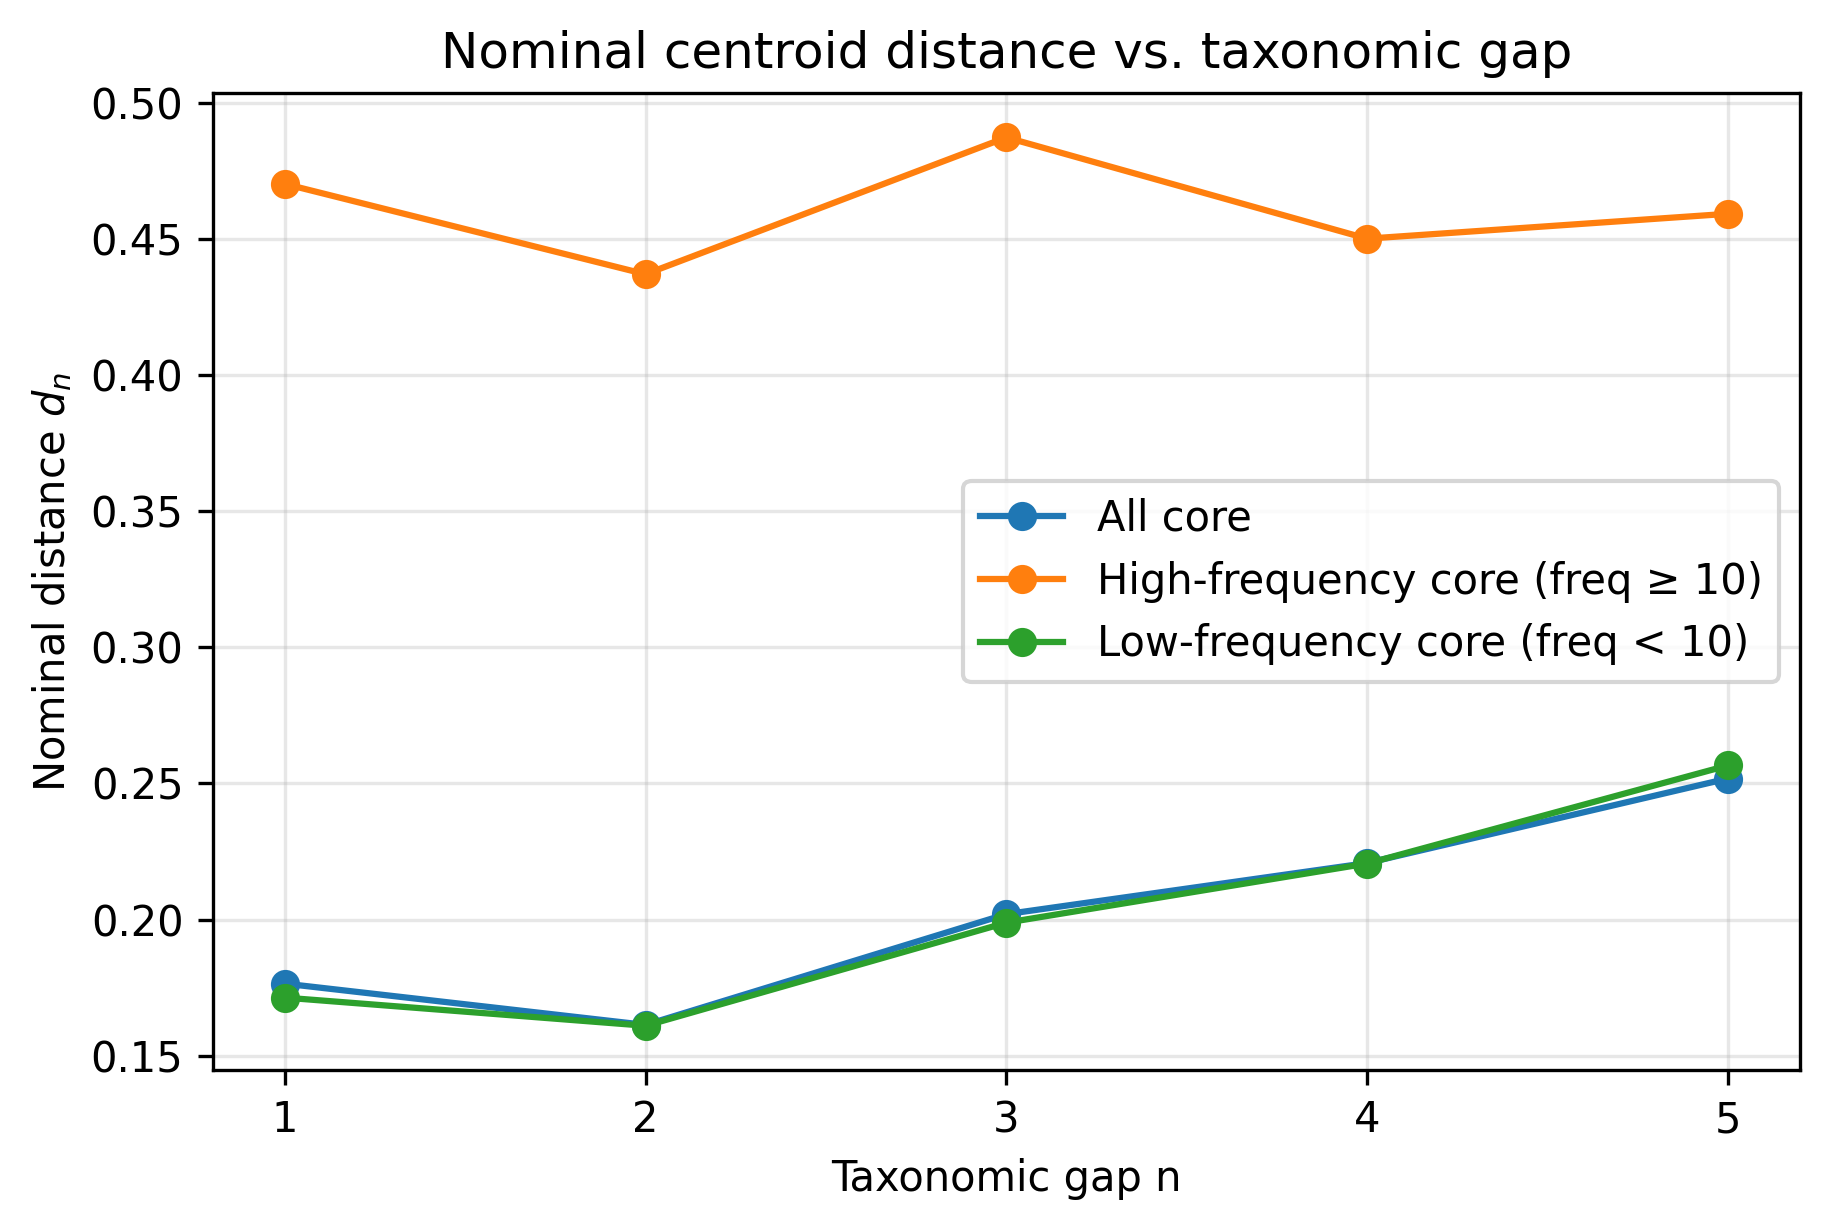

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def dn_from_table(T):
    A = T.values if hasattr(T, "values") else np.array(T)
    return [float(np.mean(np.diag(A, k=n))) for n in range(1, 6)]

dn_all  = dn_from_table(T1)
dn_high = dn_from_table(T2)
dn_low  = dn_from_table(T3)

x = [1,2,3,4,5]

plt.figure(figsize=(6.2, 4.2), dpi=300)
plt.plot(x, dn_all,  marker="o", label="All core")
plt.plot(x, dn_high, marker="o", label="High-frequency core (freq ≥ 10)")
plt.plot(x, dn_low,  marker="o", label="Low-frequency core (freq < 10)")
plt.title("Nominal centroid distance vs. taxonomic gap")
plt.xlabel("Taxonomic gap n")
plt.ylabel(r"Nominal distance $d_n$")
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("Fig1_nominal_centroid_distance_cosine.png", dpi=300, bbox_inches="tight")
plt.show()


In [34]:
# ─────────────── ⑥  EXPORT CORE VERB LIST (MPNet/string-based) ───────────────
from pathlib import Path
from collections import OrderedDict

# Collect unique verbs in original order (strings already represent lemmas)
core_verbs = OrderedDict()
for level in wordlists:
    for w in level:
        w = str(w).strip().lower()
        if w.isalpha():                 # keep alphabetic verbs only (matches your earlier filtering)
            core_verbs[w] = None

# Output path (ensure folder exists)
out_path = Path.cwd() / "results" / "BTverblist_core.txt"
out_path.parent.mkdir(parents=True, exist_ok=True)

# Write
with out_path.open("w", encoding="utf-8") as f:
    f.write("\n".join(core_verbs.keys()))

print(f"✅ Saved {len(core_verbs)} core verbs to: {out_path}")


✅ Saved 358 core verbs to: D:\Downloads\Bloom-s-Taxonomy-extension-master\Bloom-s-Taxonomy-extension-master\results\BTverblist_core.txt


In [9]:
import pathlib, os
print("BT‑n notebook cwd:", pathlib.Path.cwd())
print("core file exists :", pathlib.Path("results/BTverblist_core.txt").exists())


BT‑n notebook cwd: C:\Users\talha4\Downloads\Bloom-s-Taxonomy-extension-master\Bloom-s-Taxonomy-extension-master
core file exists : True
